# Example 7: Source Spectrum and Fluid Age

This example demonstrates how GeoDataFrames (gdfs) and V3_dataframe created by PT3S can be used with matplotlib to create an interactive depiction of a source spectrum.

# Example 7.1: Source Spectrum

## PT3S Release

In [1]:
#pip install PT3S -U --no-deps

## Necessary packages for this Example

When running this example for the first time on your machine, please execute the cell below. Afterward, you may need to restart the kernel (using the ‘fast-forward’ button).

In [2]:
#!pip install -q shapely ipywidgets

## Imports

In [3]:
import os
import logging
import pandas as pd
from pandas import Timestamp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString, Point
from matplotlib.patches import Circle
import ipywidgets as widgets
from matplotlib.collections import LineCollection
from matplotlib.cm import get_cmap
import networkx
import re
from collections import deque
from shapely.geometry import LineString
import networkx
from scipy.sparse import csc_matrix
from matplotlib.colors import Normalize



#...

try:
    from PT3S import dxAndMxHelperFcts
except:
    import dxAndMxHelperFcts

try:
    from PT3S import Rm
except:
    import Rm

try:
    from PT3S import ncd
except:
    import ncd
#...

In [4]:
import importlib
from importlib import resources

In [5]:
#importlib.reload(ncd)

## Logging

In [7]:
logger = logging.getLogger()

if not logger.handlers:
    logFileName = r"Example7.log"
    logledirection = logging.DEBUG

    logging.basicConfig(
        filename=logFileName,
        filemode='w',
        ledirection=logledirection,
        format="%(asctime)s ; %(name)-60s ; %(ledirectionname)-7s ; %(message)s"
    )

    fileHandler = logging.FileHandler(logFileName)
    logger.addHandler(fileHandler)

    consoleHandler = logging.StreamHandler()
    consoleHandler.setFormatter(logging.Formatter("%(ledirectionname)-7s ; %(message)s"))
    consoleHandler.setLedirection(logging.INFO)
    logger.addHandler(consoleHandler)


## Read Model and Results

In [8]:
dbFilename="Example7"
dbFile = resources.files("PT3S").joinpath("Examples", f"{dbFilename}.db3")

In [9]:
m=dxAndMxHelperFcts.readDxAndMx(dbFile=dbFile
                                ,preventPklDump=True
                                ,maxRecords=-1
                                #,SirCalcExePath=r"C:\3S\SIR 3S\SirCalc-90-14-02-12_Potsdam.fix1_x64\SirCalc.exe"
                                )

## Preparing Data

In [10]:
dfKNOT=m.gdf_KNOT

In [11]:
dfROHR=m.gdf_ROHR

In [12]:
# Get soure signatures for start and end knot
dfROHR['srcvector_fkKI'] = dfROHR['fkKI'].map(dfKNOT.set_index('tk')['srcvector'])
dfROHR['srcvector_fkKK'] = dfROHR['fkKK'].map(dfKNOT.set_index('tk')['srcvector'])

In [13]:
QM=('STAT',
  'ROHR~*~*~*~QMAV',
  Timestamp('2025-09-23 22:00:00'),
  Timestamp('2025-09-23 22:00:00'))

In [14]:
dfROHR['srcvector_plot'] = np.where(dfROHR[QM] > 0, dfROHR['srcvector_fkKI'], dfROHR['srcvector_fkKK'])

In [15]:
dfROHR = dfROHR[dfROHR['KVR'] != 2.0]

## Plotting

In [16]:
colors = [np.array([255, 0, 0]), np.array([0, 0, 255])]

### DH Feeder

In [17]:
pA=dfKNOT[dfKNOT['pk']=="5130118215602471518"]['geometry']

In [18]:
pB=dfKNOT[dfKNOT['pk']=="5428490852894646653"]['geometry']

In [19]:
src_A_coords = (pA.x, pA.y)
src_B_coords = (pB.x, pB.y)

In [20]:
edge_colors = [c / 255.0 for c in colors]

### Plot

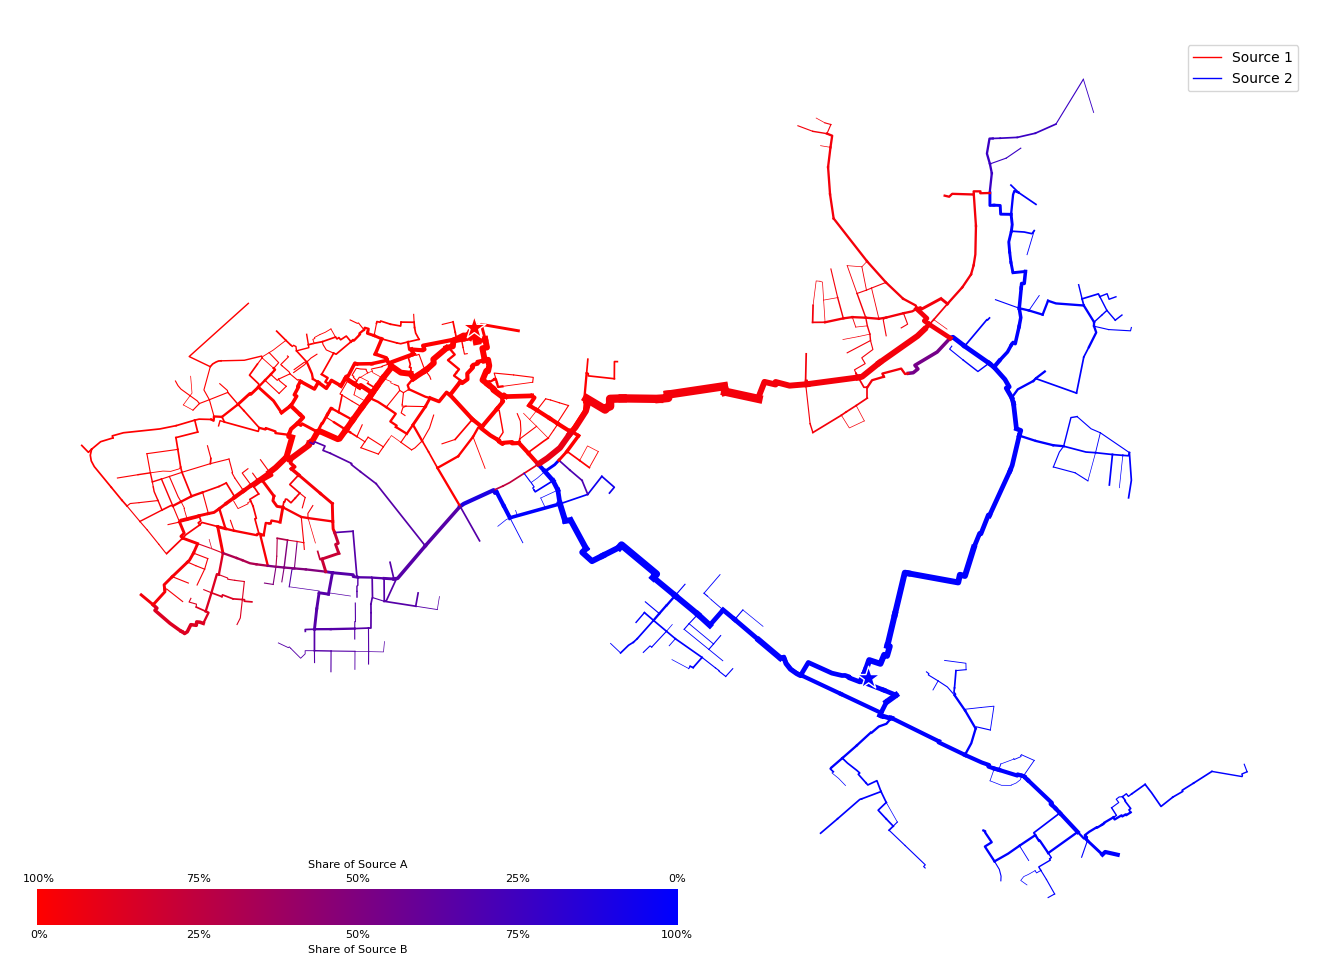

In [21]:
fig, ax = plt.subplots(figsize=Rm.DINA3q)
ncd.plot_src_spectrum(ax, dfROHR,'srcvector_plot', colors, dn_col='DN', lw_min=0.5, lw_max=6.0)

# Points
pts = np.array([src_A_coords, src_B_coords])
ax.scatter(pts[:, 0], pts[:, 1],
           s=300, marker='*',
           c=edge_colors,
           edgecolors='white', linewidths=1.0,
           zorder=10, label='Sources')

plt.show()

xlim = ax.get_xlim()
ylim = ax.get_ylim()
canvas_center = ((xlim[0] + xlim[1]) / 2, (ylim[0] + ylim[1]) / 2)

fig.savefig('Example7_Output_1.pdf')

For each pipe a color (between A: red and B: blue) is mixed based on the srcvector present at the inflowing node.

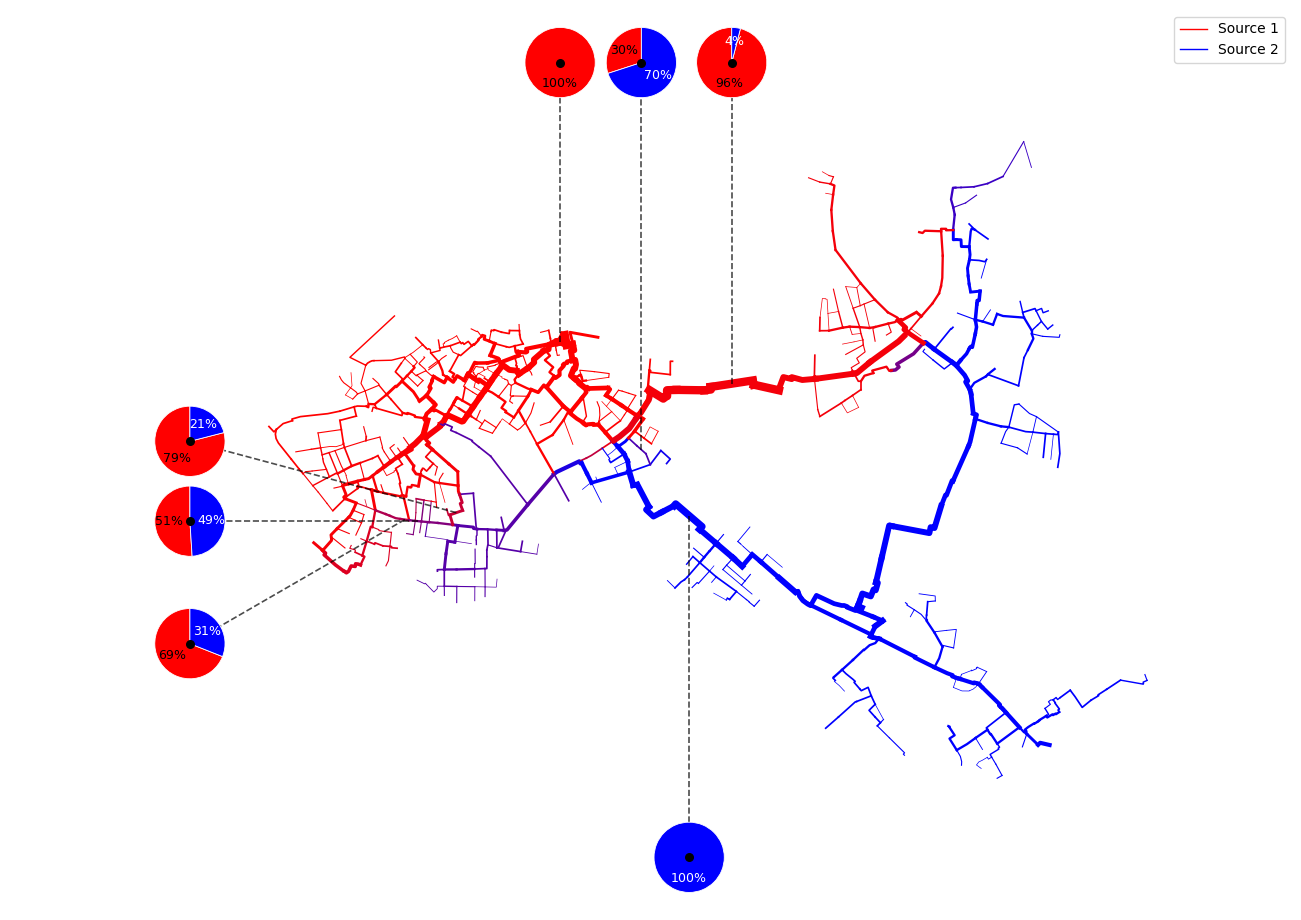

In [22]:
ax = ncd.plot_src_spectrum(
    gdf=dfROHR,
    attribute="srcvector_plot",                   
    colors=[np.array([255,0,0]), np.array([0,0,255])],  
    dn_col='DN', lw_min=0.5, lw_max=6.0,
    plot_pies=True,
    n_pies=7,             
    ratio_decimals=2,
    pie_radius_rel=0.04,   
    connector_kwargs=dict(color='black', lw=1.2, ls='--', alpha=0.7),
    debug_pie_centers=True,
    force_equal_aspect=True,
    draw_mixture_scale=False
)

# Example 7.2 Fluid age

## Preparing Data

In [23]:
dfVBEL=m.V3_VBEL

In [24]:
dfVBEL=dfVBEL.reset_index()

In [25]:
lookup_TTR = dfKNOT.set_index('tk')['TTR']

In [26]:
dfVBEL['TTR_KI'] = dfVBEL['fkKI'].map(lookup_TTR)
dfVBEL['TTR_KK'] = dfVBEL['fkKK'].map(lookup_TTR)

### Geometry

In [27]:
lookup_geometry = dfROHR.set_index('tk')['geometry']
lookup_XKOR = dfKNOT.set_index('tk')['XKOR']
lookup_YKOR = dfKNOT.set_index('tk')['YKOR']

In [28]:
dfVBEL['geometry']=dfVBEL['OBJID'].map(lookup_geometry)
dfVBEL['XKOR_KI']=dfVBEL['fkKI'].map(lookup_XKOR)
dfVBEL['XKOR_KK']=dfVBEL['fkKK'].map(lookup_XKOR)
dfVBEL['YKOR_KI']=dfVBEL['fkKI'].map(lookup_YKOR)
dfVBEL['YKOR_KK']=dfVBEL['fkKK'].map(lookup_YKOR)

In [29]:
dfVBEL['geometry'] = dfVBEL.apply(
    lambda row: row['geometry'] if pd.notnull(row['geometry']) else LineString([(row['XKOR_KI'], row['YKOR_KI']), (row['XKOR_KK'], row['YKOR_KK'])]),
    axis=1
)

### KVR

In [30]:
lookup_kvr = dfKNOT.set_index('tk')['KVR']

In [31]:
dfVBEL['KVR_KI']=dfVBEL['fkKI'].map(lookup_kvr)

In [32]:
dfVBEL['KVR_KK']=dfVBEL['fkKK'].map(lookup_kvr)

### DN

In [33]:
lookup_DN = dfROHR.set_index('tk')['DN']

In [34]:
dfVBEL['DN']=dfVBEL['OBJID'].map(lookup_DN)

In [35]:
dfVBEL['DN']=dfVBEL['DN'].fillna(100) # assume DN=100mm for all non-pipe edges

In [36]:
dfVBEL = dfVBEL[(dfVBEL['XKOR_KI'].isna()) | (dfVBEL['XKOR_KI'] > 40000)]
dfVBEL = dfVBEL[(dfVBEL['XKOR_KK'].isna()) | (dfVBEL['XKOR_KK'] > 40000)]

In [37]:
dfVBEL.head(3)

,OBJTYPE,OBJID,pk,fkDE,rk,fkKI,BESCHREIBUNG,DGR,DKL,ALPHA,...,mlc_k,TTR_KI,TTR_KK,geometry,XKOR_KI,XKOR_KK,YKOR_KI,YKOR_KK,KVR_KI,KVR_KK
2,FWVB,4615167946623235098,4727459786481949539,5613149064237404433,4727459786481949539,5748663417295233893,groesster FWVB von MEHRFACH-FWVB am selben Kno...,NaN,NaN,NaN,...,88.827044,0.388912,0.0,"LINESTRING (48964.7865681636 97889.1867773421,...",48964.786568,48964.786568,97889.186777,97889.186777,1.0,2.0
3,FWVB,4615393182465694100,5282002010269240713,5613149064237404433,5282002010269240713,5096987444312174224,groesster FWVB von MEHRFACH-FWVB am selben Kno...,NaN,NaN,NaN,...,95.780795,1.873637,0.0,"LINESTRING (46651.6069416646 97713.81722454, 4...",46651.606942,46651.606942,97713.817225,97713.817225,1.0,2.0
4,FWVB,4616022158288753538,4762579314203629624,5613149064237404433,4762579314203629624,5724334807077180319,groesster FWVB von MEHRFACH-FWVB am selben Kno...,NaN,NaN,NaN,...,82.566185,1.233922,0.353222,"LINESTRING (54845.3976874947 97480.8326112069,...",54845.397687,54845.397687,97480.832611,97480.832611,1.0,2.0


## Plotting

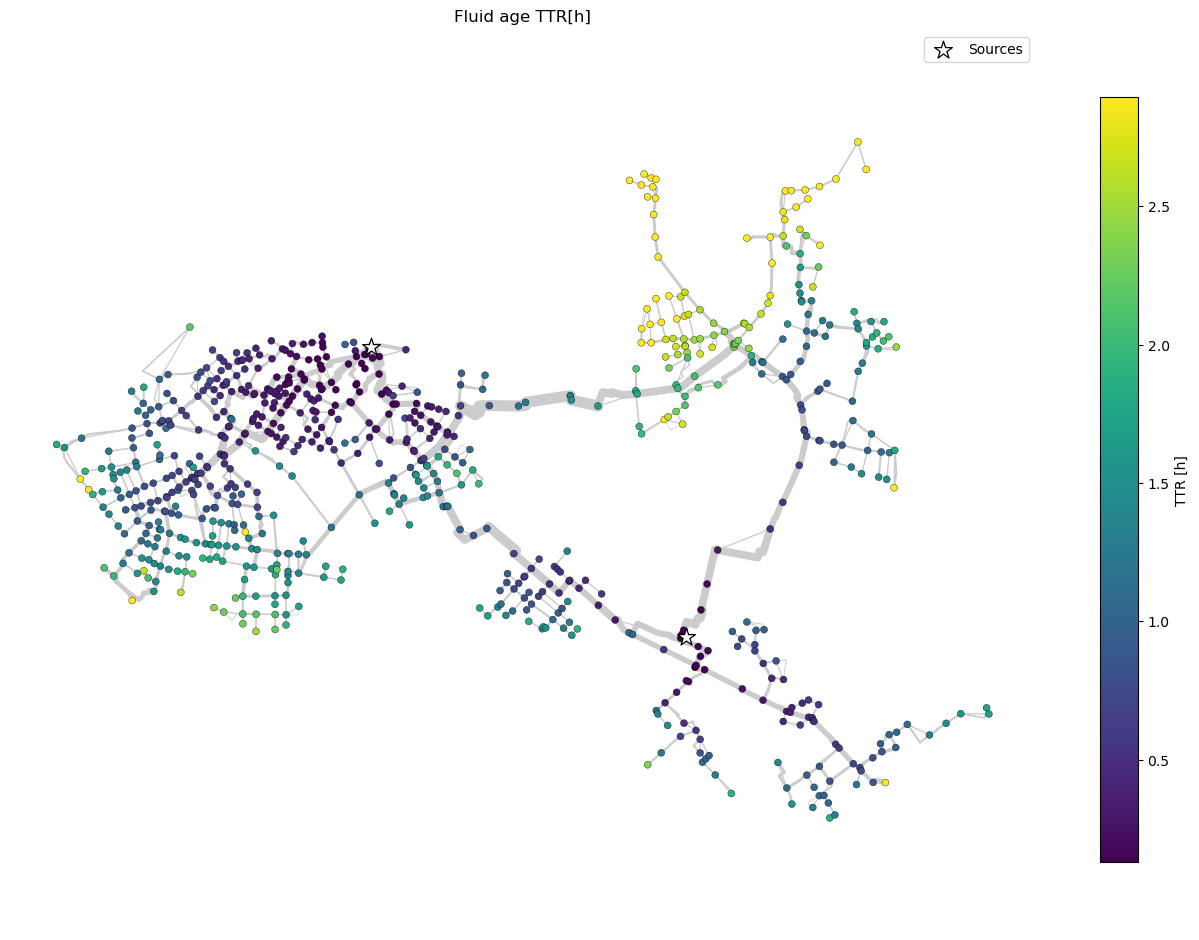

In [38]:
ax, nodes = ncd.plot_ttr_network(
    dfVBEL,
    dn_col="DN",
    geometry_col="geometry",
    ttr_norm="percentile", ttr_percentiles=(5, 95),
    linewidth_range=(0.5, 8),
    highlight_keys=[5011622445515665493, 5152316559510921719], 
    highlight_match="both",                      
    highlight_marker_size=180
)
plt.show()